### Librerias

In [225]:
import pandas as pd
import numpy as np
from utils import guardar_pickle, guardar_grafico
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


### Carga datos: pickle

In [226]:
df = pd.read_pickle('./data/clean/completo.pkl')

### PCA

In [227]:
vars_decision = [
    "inci_score",
    "medios_score",
    "calificacion_informado",
    "eco_score",
    "certificaciones",
    "precio",
    "marca",
    "ingredientes",
    "packaging",
    "reviews",
    "viral",
    "influ_score"
]

X = df[vars_decision].dropna()

In [228]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [229]:
explained_var = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza_explicada": pca.explained_variance_ratio_.round(2),
    "Varianza_acumulada": np.cumsum(pca.explained_variance_ratio_).round(2)
})
explained_var

,Componente,Varianza_explicada,Varianza_acumulada
0,PC1,0.27,0.27
1,PC2,0.17,0.43
2,PC3,0.10,0.53
3,PC4,0.09,0.62
4,PC5,0.07,0.69
5,PC6,0.07,0.76
6,PC7,0.06,0.82
7,PC8,0.05,0.86
8,PC9,0.04,0.91
9,PC10,0.04,0.95


Número óptimo de componentes: 4


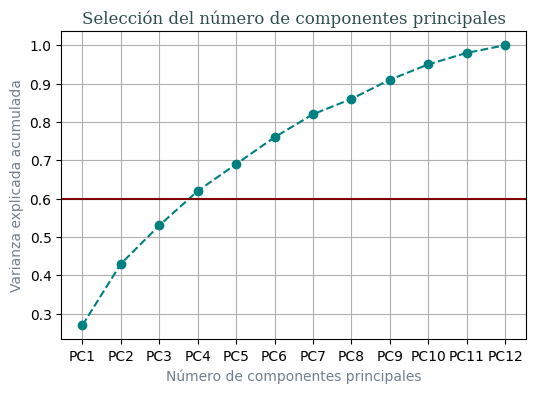

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\varianza_comp.jpg


In [230]:
umbral = 0.60
n_componentes = np.argmax(explained_var['Varianza_acumulada'] >= umbral) + 1
print(f"Número óptimo de componentes: {n_componentes}")

font_title={
    'family': 'serif',
    'color':  'darkslategray',
    'weight': 'normal',
    'size': 12,
    }

font_ax={
    'color':  'slategray',
    'weight': 'normal',
    'size': 10,
    }

fig, ax = plt.subplots(figsize=(6,4))
plt.plot(explained_var['Componente'], explained_var['Varianza_acumulada'], marker='o', linestyle='--', color='teal')
plt.axhline(y=umbral, color='maroon', linestyle='-')
ax.set_xlabel('Número de componentes principales', fontdict=font_ax)
ax.set_ylabel('Varianza explicada acumulada', fontdict=font_ax)
ax.set_title('Selección del número de componentes principales', fontdict=font_title)
ax.grid()
plt.show()

guardar_grafico(fig, 'varianza_comp')

In [231]:
peso_variables = pd.DataFrame(
    pca.components_.T.round(2),
    columns=[f"PC{i+1}" for i in range(len(vars_decision))],
    index=vars_decision
)

peso_variables

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
inci_score,0.34,-0.37,-0.01,0.16,-0.02,0.11,-0.18,-0.12,0.38,0.21,-0.64,-0.24
medios_score,0.26,-0.31,0.19,-0.27,0.18,0.38,0.53,0.07,-0.46,-0.13,-0.19,0.06
calificacion_informado,0.33,-0.40,-0.01,0.04,0.24,0.16,-0.20,0.14,0.08,0.19,0.68,-0.28
eco_score,-0.18,-0.02,0.02,0.80,-0.07,0.40,0.08,-0.19,-0.24,0.19,0.06,0.14
certificaciones,0.37,-0.02,-0.07,0.32,-0.41,-0.33,0.17,-0.03,-0.15,-0.53,0.08,-0.37
precio,0.19,0.30,-0.50,-0.29,-0.20,0.33,0.04,-0.56,-0.08,0.17,0.09,-0.18
marca,0.25,0.37,-0.12,0.02,-0.19,0.48,-0.29,0.63,-0.01,-0.15,-0.10,0.06
ingredientes,0.47,-0.15,-0.17,0.05,-0.08,-0.17,-0.08,-0.13,0.06,-0.04,0.09,0.81
packaging,0.25,0.30,0.18,0.09,0.54,-0.13,-0.46,-0.24,-0.43,-0.12,-0.14,-0.08
reviews,0.33,0.33,0.12,0.07,-0.07,-0.34,0.31,0.24,-0.14,0.69,-0.02,-0.07


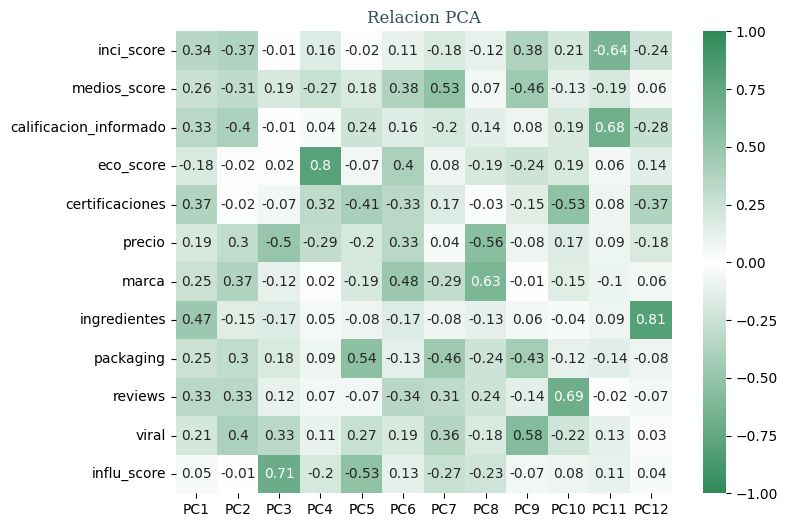

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\corr_pca.jpg


In [232]:
color_heatmap = LinearSegmentedColormap.from_list(
    "color_heatmap",
    ["seagreen", "white", "seagreen"]
)
font_title={
    'family': 'serif',
    'color':  'darkslategray',
    'weight': 'normal',
    'size': 12,
    }

font_ax={
    'color':  'slategray',
    'weight': 'normal',
    'size': 10,
    }


fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(peso_variables, annot=True, cmap=color_heatmap, center=0, vmin=-1, vmax=1)
ax.set_title("Relacion PCA", fontdict=font_title)
plt.show()
guardar_grafico(fig,'corr_pca')

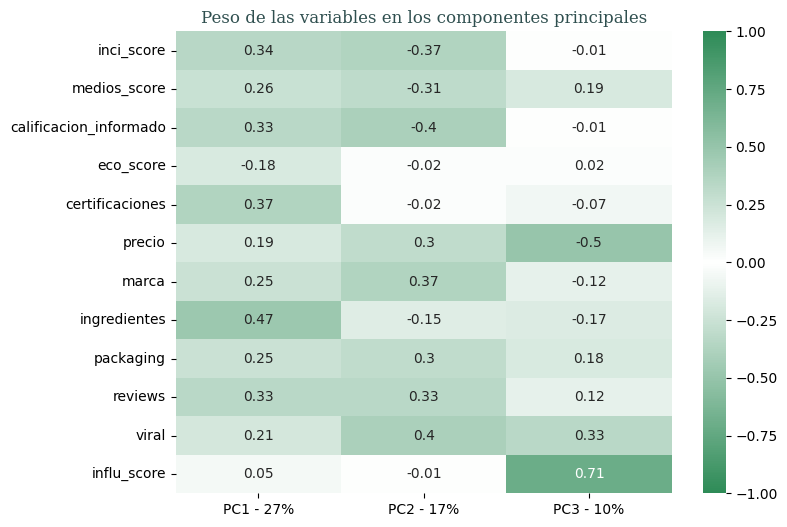

Gráfico guardado en: c:\Users\Usuario\Desktop\DataAnalytics\Proyecto\figures\corr_pesos_pca.jpg


In [233]:
pcs_relevantes = ["PC1", "PC2", "PC3"]

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(
    peso_variables[pcs_relevantes],
    annot=True,
    cmap=color_heatmap,
    center=0,
    vmin=-1,
    vmax=1
)
ax.set_title("Peso de las variables en los componentes principales", fontdict=font_title)
nuevos_labels = ["PC1 - 27%", "PC2 - 17%", "PC3 - 10%"]

ax.set_xticklabels(nuevos_labels)
plt.show()
guardar_grafico(fig,'corr_pesos_pca')

In [234]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"],
    index=df[vars_decision].dropna().index
)

### KMEANS

In [235]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df_pca["cluster"] = kmeans.fit_predict(df_pca[["PC1", "PC2", "PC3"]])

In [236]:
for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(df_pca[["PC1","PC2","PC3"]])
    
    score = silhouette_score(
        df_pca[["PC1","PC2","PC3"]],
        labels
    )
    
    print(f"k={k}, silhouette={score:.3f}")


k=2, silhouette=0.350
k=3, silhouette=0.309
k=4, silhouette=0.322
k=5, silhouette=0.316
k=6, silhouette=0.306


In [237]:
df_clusters = df.loc[df_pca.index].copy()
df_clusters["cluster"] = df_pca["cluster"]

cluster_labels = {
    0: "Informado",
    1: "Exigente",
    2: "Pragmático"
}

df_pca["perfil"] = df_pca["cluster"].map(cluster_labels)
df_clusters["perfil"] = df_clusters["cluster"].map(cluster_labels)

df_clusters.groupby("cluster")[vars_decision].mean().round(2)


,inci_score,medios_score,calificacion_informado,eco_score,certificaciones,precio,marca,ingredientes,packaging,reviews,viral,influ_score
cluster,,,,,,,,,,,,
0,1.65,0.85,3.63,0.23,3.42,3.68,2.92,4.39,2.13,3.11,1.34,0.02
1,1.00,0.40,2.83,0.23,3.38,4.26,3.91,4.04,2.96,4.21,2.51,0.02
2,0.49,0.20,2.13,0.58,1.82,3.18,2.58,2.13,1.73,2.40,1.27,0.00


In [238]:
df_pca.groupby("cluster")[["PC1","PC2","PC3"]].mean().round(2)

,PC1,PC2,PC3
cluster,,,
0,0.90,-1.11,-0.11
1,1.02,1.31,0.09
2,-2.30,0.15,0.05


In [239]:
vars_consumo = [
    "gasto_mensual_avg",
    "freq_score",
    "cant_productos_uso",
    "producto_caro"
]

df_clusters.groupby("perfil")[vars_consumo].mean().round(2)


,gasto_mensual_avg,freq_score,cant_productos_uso,producto_caro
perfil,,,,
Exigente,21.31,2.13,4.32,44.10
Informado,24.25,2.11,4.39,41.47
Pragmático,21.63,1.67,4.00,43.35


### Guardar df

In [240]:
guardar_pickle(df_pca,'pca.pkl')
df_clusters = df_clusters[['id','freq_score','inci_score','medios_score','eco_score','influ_score','cluster']]
guardar_pickle(df_clusters,'clusters.pkl')


DataFrame guardado en: C:\Users\Usuario\Desktop\DataAnalytics\Proyecto\src\data\clean\pca.pkl
DataFrame guardado en: C:\Users\Usuario\Desktop\DataAnalytics\Proyecto\src\data\clean\clusters.pkl
